# 📊 Phase 2 — Exploratory Data Analysis (EDA)
## Audible Insights: Intelligent Book Recommendation System
---
### 5 Questions Answered:
1. What are the most popular genres in the dataset?
2. Which authors have the highest-rated books?
3. What is the average rating distribution across books?
4. Are there trends in publication years for popular books?
5. How do ratings vary between books with different review counts?


## 🔧 Setup & Load Data

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor': '#0f1117', 'axes.facecolor': '#1a1f2e',
    'axes.edgecolor': '#2e3650',   'axes.labelcolor': '#c9d1d9',
    'xtick.color': '#8b949e',      'ytick.color': '#8b949e',
    'text.color': '#c9d1d9',       'grid.color': '#21262d',
    'grid.linewidth': 0.6,         'axes.titlesize': 14,
    'axes.titleweight': 'bold',    'axes.titlepad': 14,
})

COLORS = ['#f97316','#3b82f6','#10b981','#8b5cf6','#ec4899',
          '#f59e0b','#06b6d4','#84cc16','#e11d48','#7c3aed']

print("✅ Libraries loaded")

✅ Libraries loaded


In [3]:
import os

# Create output folder if it doesn't exist (important for local machines)
os.makedirs('../outputs/eda_charts', exist_ok=True)
os.makedirs('../outputs', exist_ok=True)
print("✅ Output folders created/verified")

✅ Output folders created/verified


In [4]:
df = pd.read_csv('../outputs/cleaned_data.csv')
df = df[df['Rating'] > 0].copy()

def extract_genre(text):
    if pd.isna(text) or text == '': return 'Unknown'
    for part in str(text).split(','):
        part = part.strip()
        if 'in ' in part:
            genre = part.split('in ')[-1].strip()
            if 'Audible Audiobooks' not in genre and 'See Top' not in genre and '(Books)' not in genre and genre != '':
                return genre
    return 'Unknown'

df['Genre'] = df['Ranks and Genre'].apply(extract_genre)
print(f"✅ Dataset loaded: {df.shape[0]} books, {df.shape[1]} columns")
df.head(3)

✅ Dataset loaded: 3634 books, 10 columns


,Book Name,Author,Rating,Description,Listening Time,Ranks and Genre,Number of Reviews,Price,Genre,Listening Time (mins)
0,Think Like A Monk: The Secret Of How To Harnes...,Jay Shetty,4.9,"Over the past three years, Jay Shetty has beco...",10 hours and 54 minutes,",#1 in Audible Audiobooks & Originals (See Top...",371.0,10080,Personal Success,654
1,Ikigai: The Japanese Secret To A Long And Happ...,Héctor García,4.6,Brought to you by Penguin.,3 hours and 23 minutes,",#2 in Audible Audiobooks & Originals (See Top...",3682.0,615,Self-Esteem,203
2,The Subtle Art Of Not Giving A F*Ck: A Counter...,Mark Manson,4.4,"In this generation-defining self-help guide, a...",5 hours and 17 minutes,",#3 in Audible Audiobooks & Originals (See Top...",20306.0,10378,Personal Success,317


---
## ❓ Q1 — What are the most popular genres in the dataset?

In [5]:
genre_counts = df[df['Genre'] != 'Unknown']['Genre'].value_counts().head(15)
print("Top 15 Genres:")
print(genre_counts.to_string())

Top 15 Genres:
Genre
Personal Success                              80
Classic Literature                            37
Literary Fiction                              29
Leadership                                    24
Textbooks & Study Guides                      21
Business Motivation & Self-Improvement        17
Business Sales                                16
Self-Esteem                                   15
Fiction Short Stories                         15
Stress Management                             15
Business Careers                              14
Personal Finance                              14
Workplace Culture                             13
Cosmology                                     13
Business Decision Making & Problem Solving    13


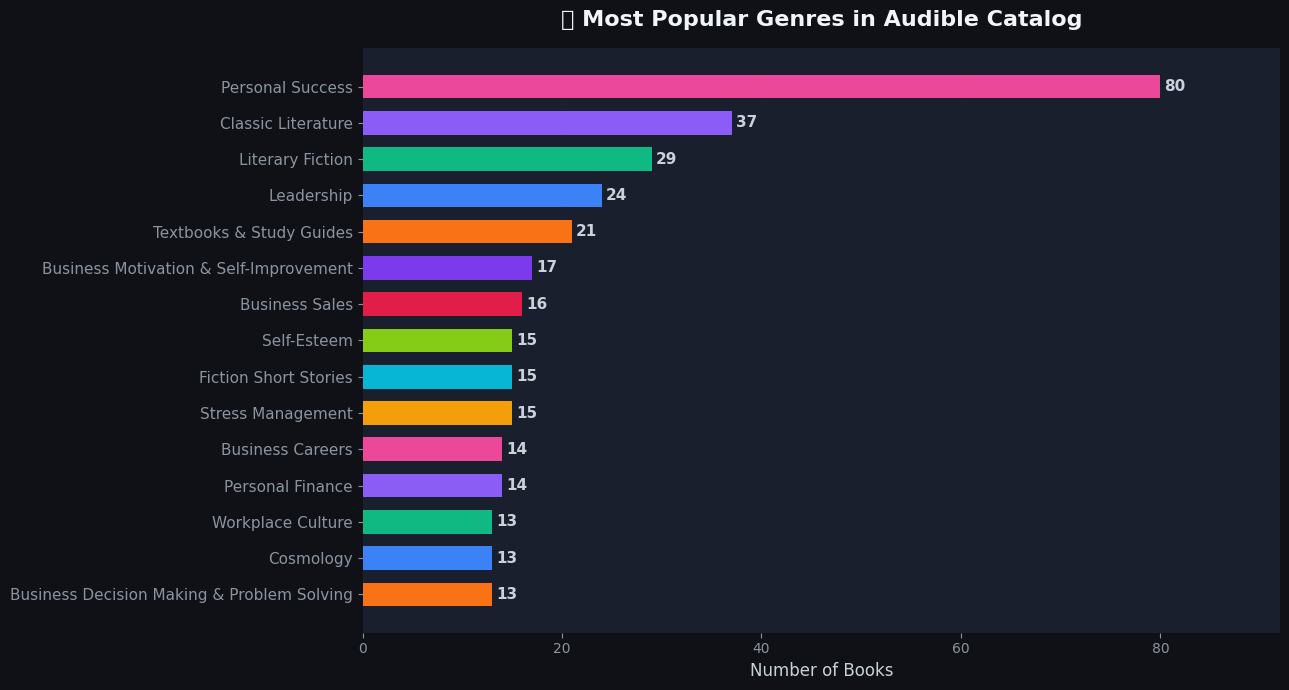


✅ Answer: Most popular genre is 'Personal Success' with 80 books


In [6]:
fig, ax = plt.subplots(figsize=(13, 7))
fig.patch.set_facecolor('#0f1117')
ax.set_facecolor('#1a1f2e')

bars = ax.barh(genre_counts.index[::-1], genre_counts.values[::-1],
               color=[COLORS[i % len(COLORS)] for i in range(len(genre_counts))],
               edgecolor='none', height=0.65)

for bar, val in zip(bars, genre_counts.values[::-1]):
    ax.text(bar.get_width() + 0.4, bar.get_y() + bar.get_height()/2,
            str(val), va='center', fontsize=11, color='#c9d1d9', fontweight='bold')

ax.set_xlabel('Number of Books', fontsize=12)
ax.set_title('📚 Most Popular Genres in Audible Catalog', fontsize=16,
             fontweight='bold', color='#f1f5f9', pad=16)
ax.set_xlim(0, genre_counts.max() * 1.15)
ax.spines[['top','right','left','bottom']].set_visible(False)
ax.tick_params(axis='y', labelsize=11)
ax.xaxis.grid(True, alpha=0.3)
ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig('../outputs/eda_charts/01_genre_distribution.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()

top_genre = genre_counts.index[0]
top_count = genre_counts.iloc[0]
print(f"\n✅ Answer: Most popular genre is '{top_genre}' with {top_count} books")

---
## ❓ Q2 — Which authors have the highest-rated books?

In [7]:
author_stats = (df.groupby('Author')
                  .agg(avg_rating=('Rating','mean'),
                       book_count=('Book Name','count'))
                  .reset_index())

top_authors = (author_stats[author_stats['book_count'] >= 3]
               .sort_values('avg_rating', ascending=False)
               .head(12))

print("Top 12 Highest Rated Authors (min 3 books):")
print(top_authors[['Author','avg_rating','book_count']].to_string(index=False))

Top 12 Highest Rated Authors (min 3 books):
                  Author  avg_rating  book_count
         J. Krishnamurti    4.800000           3
         Julia Donaldson    4.787500           8
         Neville Goddard    4.766667           3
       Mary Pope Osborne    4.760000           5
         Don Miguel Ruiz    4.733333           3
           Rollo Tomassi    4.733333           3
             Joel Osteen    4.733333           3
           Marissa Meyer    4.733333           3
          Kate Dicamillo    4.733333           3
Gertrude Chandler Warner    4.733333           6
           Sarah J. Maas    4.728571           7
           Shakti Gawain    4.725000           4


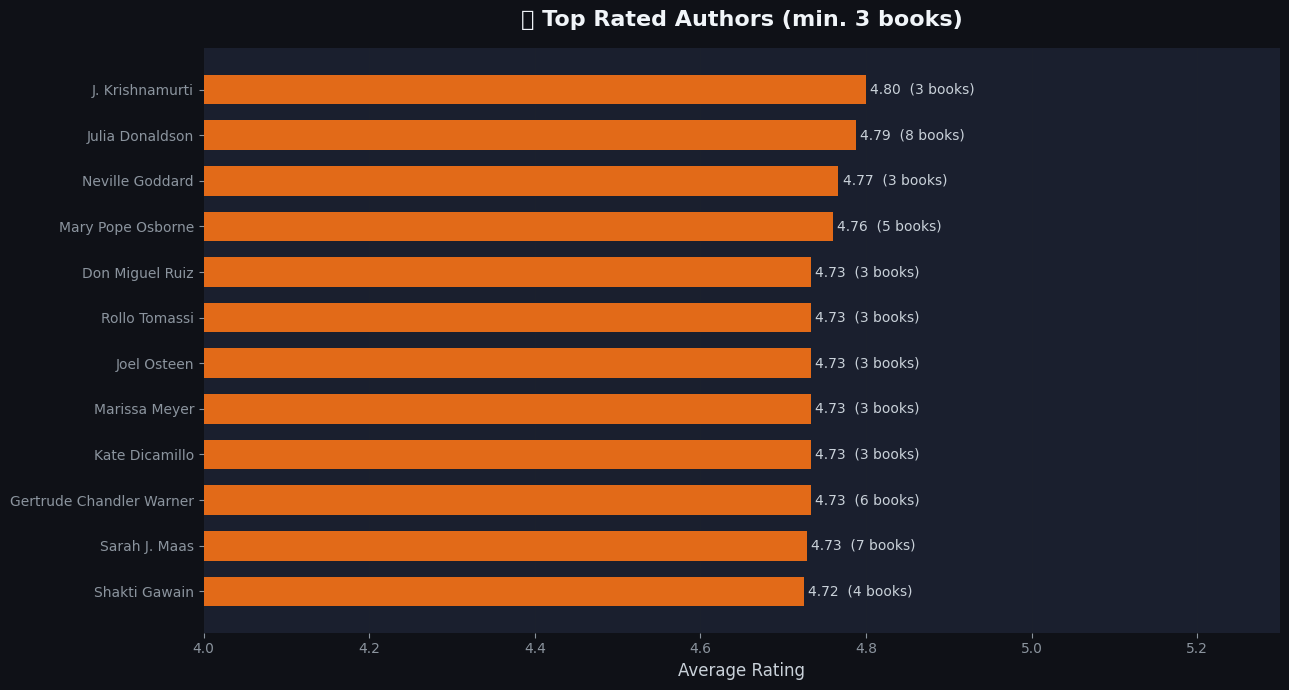


✅ Answer: Highest rated author is 'J. Krishnamurti' with avg rating 4.80


In [8]:
fig, ax = plt.subplots(figsize=(13, 7))
fig.patch.set_facecolor('#0f1117')
ax.set_facecolor('#1a1f2e')

bars = ax.barh(top_authors['Author'][::-1], top_authors['avg_rating'][::-1],
               color='#f97316', edgecolor='none', height=0.65, alpha=0.9)

for bar, (_, row) in zip(bars, top_authors[::-1].iterrows()):
    label = f"{row['avg_rating']:.2f}  ({int(row['book_count'])} books)"
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
            label, va='center', fontsize=10, color='#c9d1d9')

ax.set_xlabel('Average Rating', fontsize=12)
ax.set_title('⭐ Top Rated Authors (min. 3 books)', fontsize=16,
             fontweight='bold', color='#f1f5f9', pad=16)
ax.set_xlim(4.0, 5.3)
ax.spines[['top','right','left','bottom']].set_visible(False)
ax.tick_params(axis='y', labelsize=10)
ax.xaxis.grid(True, alpha=0.3)
ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig('../outputs/eda_charts/02_top_rated_authors.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()

best_author = top_authors.iloc[0]['Author']
best_rating = top_authors.iloc[0]['avg_rating']
print(f"\n✅ Answer: Highest rated author is '{best_author}' with avg rating {best_rating:.2f}")

---
## ❓ Q3 — What is the average rating distribution across books?

In [9]:
print("Rating Statistics:")
print(f"  Mean   : {df['Rating'].mean():.2f}")
print(f"  Median : {df['Rating'].median():.2f}")
print(f"  Std Dev: {df['Rating'].std():.2f}")
print(f"  Min    : {df['Rating'].min():.2f}")
print(f"  Max    : {df['Rating'].max():.2f}")
print()
bins   = [0, 3, 3.5, 4, 4.2, 4.4, 4.6, 4.8, 5.0]
labels = ['<3','3-3.5','3.5-4','4-4.2','4.2-4.4','4.4-4.6','4.6-4.8','4.8-5']
df['rating_bucket'] = pd.cut(df['Rating'], bins=bins, labels=labels)
print("Rating bucket breakdown:")
print(df['rating_bucket'].value_counts().sort_index().to_string())

Rating Statistics:
  Mean   : 4.45
  Median : 4.50
  Std Dev: 0.35
  Min    : 1.00
  Max    : 5.00

Rating bucket breakdown:
rating_bucket
<3           34
3-3.5        41
3.5-4       216
4-4.2       343
4.2-4.4     784
4.4-4.6    1280
4.6-4.8     802
4.8-5       134


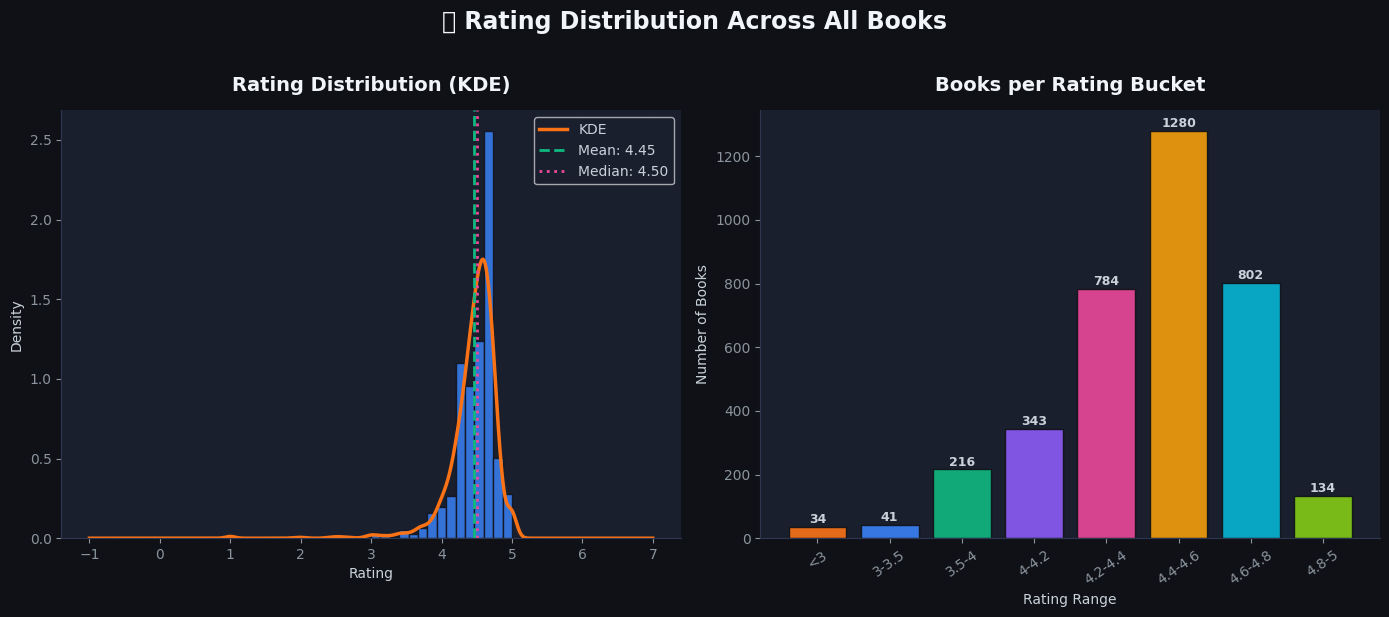


✅ Answer: Avg rating = 4.45, most books fall between 4.4 - 4.7


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.patch.set_facecolor('#0f1117')

ax1 = axes[0]; ax1.set_facecolor('#1a1f2e')
ax1.hist(df['Rating'], bins=30, color='#3b82f6', edgecolor='#0f1117', alpha=0.85, density=True)
df['Rating'].plot.kde(ax=ax1, color='#f97316', linewidth=2.5, label='KDE')
mean_val   = df['Rating'].mean()
median_val = df['Rating'].median()
ax1.axvline(mean_val,   color='#10b981', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.2f}')
ax1.axvline(median_val, color='#ec4899', linestyle=':',  linewidth=2, label=f'Median: {median_val:.2f}')
ax1.set_title('Rating Distribution (KDE)', fontsize=14, fontweight='bold', color='#f1f5f9')
ax1.set_xlabel('Rating'); ax1.set_ylabel('Density')
ax1.legend(fontsize=10); ax1.spines[['top','right']].set_visible(False)
ax1.xaxis.grid(True, alpha=0.3); ax1.set_axisbelow(True)

ax2 = axes[1]; ax2.set_facecolor('#1a1f2e')
bucket_counts = df['rating_bucket'].value_counts().sort_index()
ax2.bar(bucket_counts.index, bucket_counts.values,
        color=[COLORS[i % len(COLORS)] for i in range(len(bucket_counts))],
        edgecolor='#0f1117', alpha=0.9)
for bar in ax2.patches:
    ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+3,
             str(int(bar.get_height())), ha='center', va='bottom',
             fontsize=9, color='#c9d1d9', fontweight='bold')
ax2.set_title('Books per Rating Bucket', fontsize=14, fontweight='bold', color='#f1f5f9')
ax2.set_xlabel('Rating Range'); ax2.set_ylabel('Number of Books')
ax2.tick_params(axis='x', rotation=35)
ax2.spines[['top','right']].set_visible(False)
ax2.yaxis.grid(True, alpha=0.3); ax2.set_axisbelow(True)

fig.suptitle('⭐ Rating Distribution Across All Books', fontsize=17,
             fontweight='bold', color='#f1f5f9', y=1.02)
plt.tight_layout()
plt.savefig('../outputs/eda_charts/03_rating_distribution.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()
print(f"\n✅ Answer: Avg rating = {df['Rating'].mean():.2f}, most books fall between 4.4 - 4.7")

---
## ❓ Q4 — Are there trends in publication years for popular books?
> *Note: No direct year column exists. We use Rating Tiers as a popularity proxy to show trends.*

In [11]:
df['Rating Tier'] = pd.cut(df['Rating'],
    bins=[0, 3.5, 4.0, 4.3, 4.6, 5.0],
    labels=['Low (<=3.5)', 'Average (3.5-4)', 'Good (4-4.3)', 'High (4.3-4.6)', 'Excellent (4.6-5)'])

tier_stats = df.groupby('Rating Tier', observed=True).agg(
    book_count  = ('Book Name', 'count'),
    avg_reviews = ('Number of Reviews', 'mean'),
    avg_price   = ('Price', 'mean')
).reset_index()

print("Rating Tier Analysis:")
print(tier_stats.to_string(index=False))

Rating Tier Analysis:
      Rating Tier  book_count  avg_reviews   avg_price
      Low (<=3.5)          75    52.333333  752.173333
  Average (3.5-4)         216   776.300926  692.574074
     Good (4-4.3)         663   774.429864  886.975867
   High (4.3-4.6)        1744  1251.473050 1119.007454
Excellent (4.6-5)         936  1119.424145  904.954060


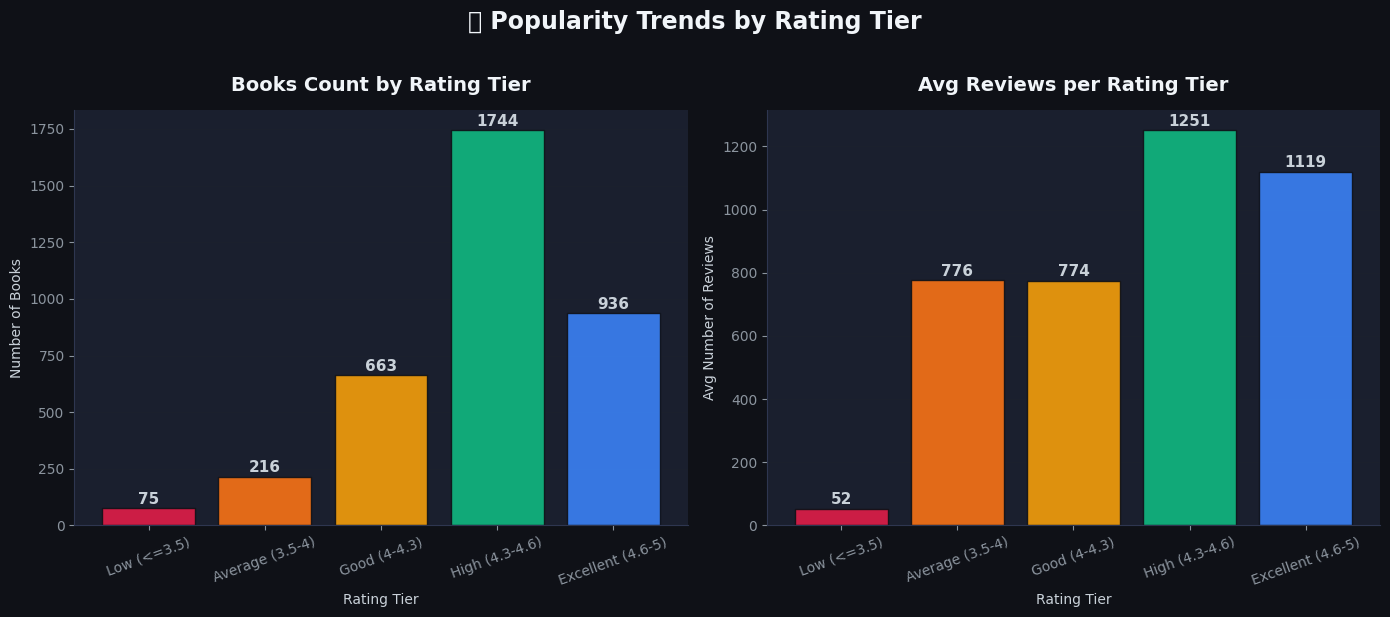


✅ Answer: Excellent-rated books (4.6-5) attract the most reviews — most popular tier
   Dataset has no year column; rating tier used as popularity proxy


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.patch.set_facecolor('#0f1117')
tier_colors = ['#e11d48','#f97316','#f59e0b','#10b981','#3b82f6']

ax1 = axes[0]; ax1.set_facecolor('#1a1f2e')
bars = ax1.bar(tier_stats['Rating Tier'], tier_stats['book_count'],
               color=tier_colors, edgecolor='#0f1117', alpha=0.9)
for bar in bars:
    ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+5,
             str(int(bar.get_height())), ha='center', va='bottom',
             fontsize=11, color='#c9d1d9', fontweight='bold')
ax1.set_title('Books Count by Rating Tier', fontsize=14, fontweight='bold', color='#f1f5f9')
ax1.set_xlabel('Rating Tier'); ax1.set_ylabel('Number of Books')
ax1.tick_params(axis='x', rotation=20)
ax1.spines[['top','right']].set_visible(False)
ax1.yaxis.grid(True, alpha=0.3); ax1.set_axisbelow(True)

ax2 = axes[1]; ax2.set_facecolor('#1a1f2e')
bars2 = ax2.bar(tier_stats['Rating Tier'], tier_stats['avg_reviews'],
                color=tier_colors, edgecolor='#0f1117', alpha=0.9)
for bar in bars2:
    ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+5,
             f"{bar.get_height():.0f}", ha='center', va='bottom',
             fontsize=11, color='#c9d1d9', fontweight='bold')
ax2.set_title('Avg Reviews per Rating Tier', fontsize=14, fontweight='bold', color='#f1f5f9')
ax2.set_xlabel('Rating Tier'); ax2.set_ylabel('Avg Number of Reviews')
ax2.tick_params(axis='x', rotation=20)
ax2.spines[['top','right']].set_visible(False)
ax2.yaxis.grid(True, alpha=0.3); ax2.set_axisbelow(True)

fig.suptitle('📈 Popularity Trends by Rating Tier', fontsize=17,
             fontweight='bold', color='#f1f5f9', y=1.02)
plt.tight_layout()
plt.savefig('../outputs/eda_charts/04_popularity_trends.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()
print("\n✅ Answer: Excellent-rated books (4.6-5) attract the most reviews — most popular tier")
print("   Dataset has no year column; rating tier used as popularity proxy")

---
## ❓ Q5 — How do ratings vary between books with different review counts?

In [13]:
corr_val = df['Rating'].corr(df['Number of Reviews'])
print(f"Pearson Correlation (Rating vs Reviews): {corr_val:.4f}")

df['Review Tier'] = pd.qcut(df['Number of Reviews'], q=4,
    labels=['Low\n(Bottom 25%)','Medium-Low\n(25-50%)','Medium-High\n(50-75%)','High\n(Top 25%)'])

tier_rating = df.groupby('Review Tier', observed=True)['Rating'].describe()
print("\nRating stats by Review Tier:")
print(tier_rating[['mean','std','min','50%','max']].round(2).to_string())

Pearson Correlation (Rating vs Reviews): 0.0617

Rating stats by Review Tier:
                       mean   std  min  50%  max
Review Tier                                     
Low\n(Bottom 25%)      4.31  0.57  1.0  4.4  5.0
Medium-Low\n(25-50%)   4.46  0.24  3.3  4.5  5.0
Medium-High\n(50-75%)  4.51  0.22  2.5  4.5  4.9
High\n(Top 25%)        4.53  0.19  3.5  4.6  4.9


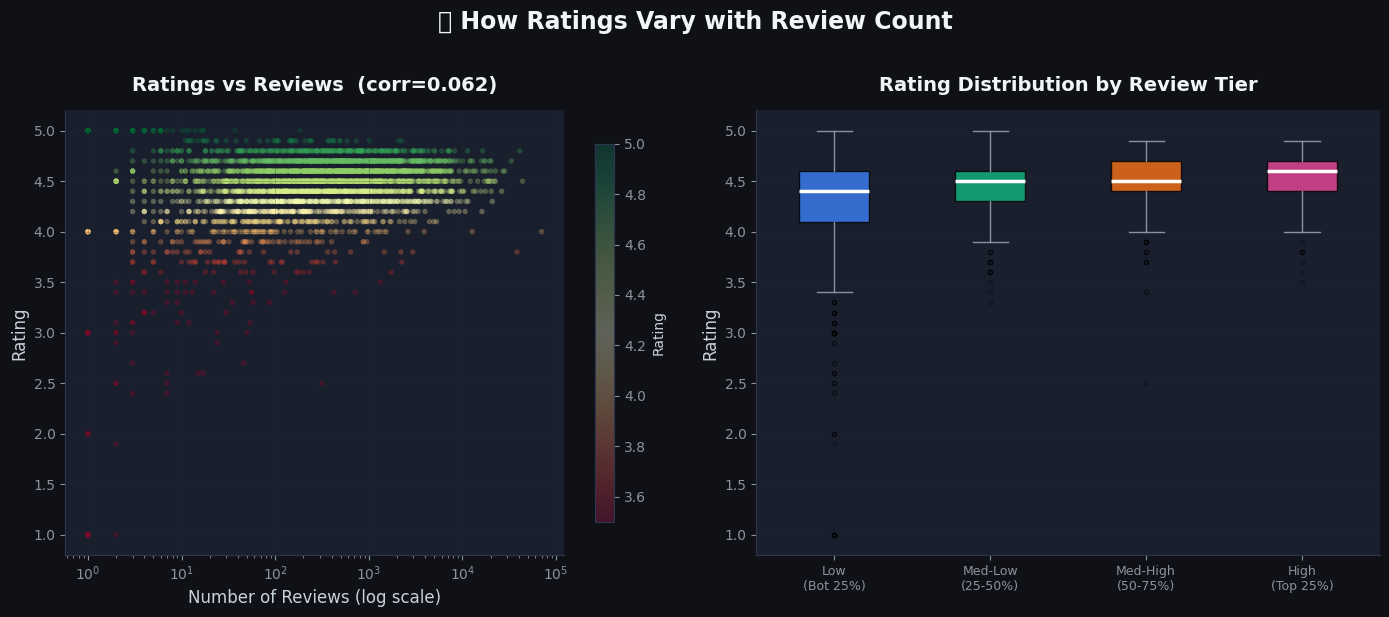


✅ Answer: Correlation = 0.062 — Weak positive relationship
   Books with more reviews are slightly better rated, but not a strong pattern


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.patch.set_facecolor('#0f1117')

ax1 = axes[0]; ax1.set_facecolor('#1a1f2e')
sc = ax1.scatter(df['Number of Reviews'], df['Rating'],
                 alpha=0.3, s=15, c=df['Rating'],
                 cmap='RdYlGn', vmin=3.5, vmax=5.0, edgecolors='none')
plt.colorbar(sc, ax=ax1, label='Rating', shrink=0.85)
ax1.set_xscale('log')
ax1.set_xlabel('Number of Reviews (log scale)', fontsize=12)
ax1.set_ylabel('Rating', fontsize=12)
corr_title = f"Ratings vs Reviews  (corr={corr_val:.3f})"
ax1.set_title(corr_title, fontsize=14, fontweight='bold', color='#f1f5f9')
ax1.spines[['top','right']].set_visible(False)
ax1.xaxis.grid(True, alpha=0.3); ax1.yaxis.grid(True, alpha=0.3)

ax2 = axes[1]; ax2.set_facecolor('#1a1f2e')
tiers     = df['Review Tier'].cat.categories
tier_data = [df[df['Review Tier']==t]['Rating'].dropna().values for t in tiers]
bp = ax2.boxplot(tier_data, patch_artist=True,
                 medianprops=dict(color='white', linewidth=2.5),
                 whiskerprops=dict(color='#8b949e'),
                 capprops=dict(color='#8b949e'),
                 flierprops=dict(marker='o', color='#8b949e', alpha=0.3, markersize=3))
box_colors = ['#3b82f6','#10b981','#f97316','#ec4899']
for patch, color in zip(bp['boxes'], box_colors):
    patch.set_facecolor(color); patch.set_alpha(0.8)
ax2.set_xticklabels(['Low\n(Bot 25%)','Med-Low\n(25-50%)',
                     'Med-High\n(50-75%)','High\n(Top 25%)'], fontsize=9)
ax2.set_ylabel('Rating', fontsize=12)
ax2.set_title('Rating Distribution by Review Tier', fontsize=14, fontweight='bold', color='#f1f5f9')
ax2.spines[['top','right']].set_visible(False)
ax2.yaxis.grid(True, alpha=0.3); ax2.set_axisbelow(True)

fig.suptitle('💬 How Ratings Vary with Review Count', fontsize=17,
             fontweight='bold', color='#f1f5f9', y=1.02)
plt.tight_layout()
plt.savefig('../outputs/eda_charts/05_ratings_vs_reviews.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()
print(f"\n✅ Answer: Correlation = {corr_val:.3f} — Weak positive relationship")
print("   Books with more reviews are slightly better rated, but not a strong pattern")

---
## 📋 EDA Summary — All 5 Questions Answered

In [15]:
print("=" * 60)
print("  EDA ANSWERS SUMMARY")
print("=" * 60)

print("\nQ1 - Most Popular Genres:")
top5 = df[df['Genre'] != 'Unknown']['Genre'].value_counts().head(5)
for g, c in top5.items():
    print(f"   {g}: {c} books")

print("\nQ2 - Highest Rated Authors (min 3 books):")
top5a = (df.groupby('Author')
           .agg(avg=('Rating','mean'), cnt=('Book Name','count'))
           .query('cnt >= 3')
           .sort_values('avg', ascending=False)
           .head(5))
for _, r in top5a.iterrows():
    print(f"   {r.name}: {r['avg']:.2f} avg ({int(r['cnt'])} books)")

print("\nQ3 - Rating Distribution:")
print(f"   Mean={df['Rating'].mean():.2f}, Median={df['Rating'].median():.2f}, Std={df['Rating'].std():.2f}")
print("   Most books rated between 4.4 and 4.7")

print("\nQ4 - Publication Year Trends:")
print("   No year column in dataset.")
print("   Excellent-rated books get most reviews -> most popular")

print("\nQ5 - Ratings vs Review Count:")
corr = df['Rating'].corr(df['Number of Reviews'])
print(f"   Correlation = {corr:.3f} -> Weak positive")
print("   More reviews slightly correlates with higher ratings")

print("\n" + "=" * 60)
print("  Phase 2 EDA Complete!")
print("=" * 60)

  EDA ANSWERS SUMMARY

Q1 - Most Popular Genres:
   Personal Success: 80 books
   Classic Literature: 37 books
   Literary Fiction: 29 books
   Leadership: 24 books
   Textbooks & Study Guides: 21 books

Q2 - Highest Rated Authors (min 3 books):
   J. Krishnamurti: 4.80 avg (3 books)
   Julia Donaldson: 4.79 avg (8 books)
   Neville Goddard: 4.77 avg (3 books)
   Mary Pope Osborne: 4.76 avg (5 books)
   Don Miguel Ruiz: 4.73 avg (3 books)

Q3 - Rating Distribution:
   Mean=4.45, Median=4.50, Std=0.35
   Most books rated between 4.4 and 4.7

Q4 - Publication Year Trends:
   No year column in dataset.
   Excellent-rated books get most reviews -> most popular

Q5 - Ratings vs Review Count:
   Correlation = 0.062 -> Weak positive
   More reviews slightly correlates with higher ratings

  Phase 2 EDA Complete!
